In [1]:
import kagglehub
import os
import pandas as pd

path = kagglehub.dataset_download("hayaalwizrah1/gold-price-prediction-dataset-20002026")
data = pd.read_csv(os.path.join(path, 'gold_data.csv'))

c:\Users\haya5\AppData\Local\Programs\Python\Python313\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
df = data.copy()

In [3]:
df = df.set_index("Date")

In [4]:
df.loc['2002-02-14']

Gold_Open        300.000000
Gold_High        300.500000
Gold_Low         299.399994
Gold_Close       299.700012
Gold_Volume       20.000000
DXY              118.430000
SP500           1116.479980
Oil               21.219999
VIX               21.770000
Lag1             299.399994
Lag7             298.200012
MA7              300.085720
MA30             287.063333
EMA20            291.962793
Daily_Return       0.001002
RSI               68.829643
MACD               5.500935
MACD_Signal        4.344156
MACD_Hist          1.156780
BB_Upper         307.481856
BB_Middle        289.115001
BB_Lower         270.748146
ATR                3.761646
Target           298.399994
Name: 2002-02-14, dtype: float64

In [5]:
df.columns

Index(['Gold_Open', 'Gold_High', 'Gold_Low', 'Gold_Close', 'Gold_Volume',
       'DXY', 'SP500', 'Oil', 'VIX', 'Lag1', 'Lag7', 'MA7', 'MA30', 'EMA20',
       'Daily_Return', 'RSI', 'MACD', 'MACD_Signal', 'MACD_Hist', 'BB_Upper',
       'BB_Middle', 'BB_Lower', 'ATR', 'Target'],
      dtype='str')

In [6]:
y = df['Target']
X = df.drop(columns=['Gold_Open', 'Gold_High', 'Gold_Low', 'Gold_Volume', 'ATR', 'Target'])

In [7]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, shuffle=False)

In [8]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()

s_train = scaler.fit_transform(X_train)
s_test = scaler.transform(X_test)

X_train = pd.DataFrame(s_train, columns = X.columns, index = X_train.index)
X_test = pd.DataFrame(s_test, columns = X.columns, index = X_test.index)

In [25]:
from GoldPricePredictor import GoldPricePredictor

model = GoldPricePredictor()
model.train(X_train, y_train, es_patience=5, lr=0.005)

Epoch 1/200
130/130 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - loss: 260714.6250 - mae: 348.5010 - val_loss: 110153.8906 - val_mae: 257.8479
Epoch 2/200
130/130 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 25813.7051 - mae: 118.0545 - val_loss: 72122.1562 - val_mae: 216.1134
Epoch 3/200
130/130 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 19266.6250 - mae: 102.8385 - val_loss: 28611.6016 - val_mae: 131.2869
Epoch 4/200
130/130 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 16790.7734 - mae: 95.3693 - val_loss: 9751.8018 - val_mae: 72.8255
Epoch 5/200
130/130 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 14368.3398 - mae: 87.5884 - val_loss: 21985.6855 - val_mae: 125.9188
Epoch 6/200
130/130 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 14054.7354 - mae: 86.4660 - val_loss: 10076.5371 - val_mae: 79.6518
Epoch 7/200
130/130 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 14552.4795 - mae: 86.3423 - val_loss: 2757.2927 - val_mae: 38.5463
Epoch 8/200
130/130 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 12795.9717 - mae: 81.2663 - v

RMSE : 120.8623996448927
MAE  : 86.22789140609906
R²   : 0.9845463156115486


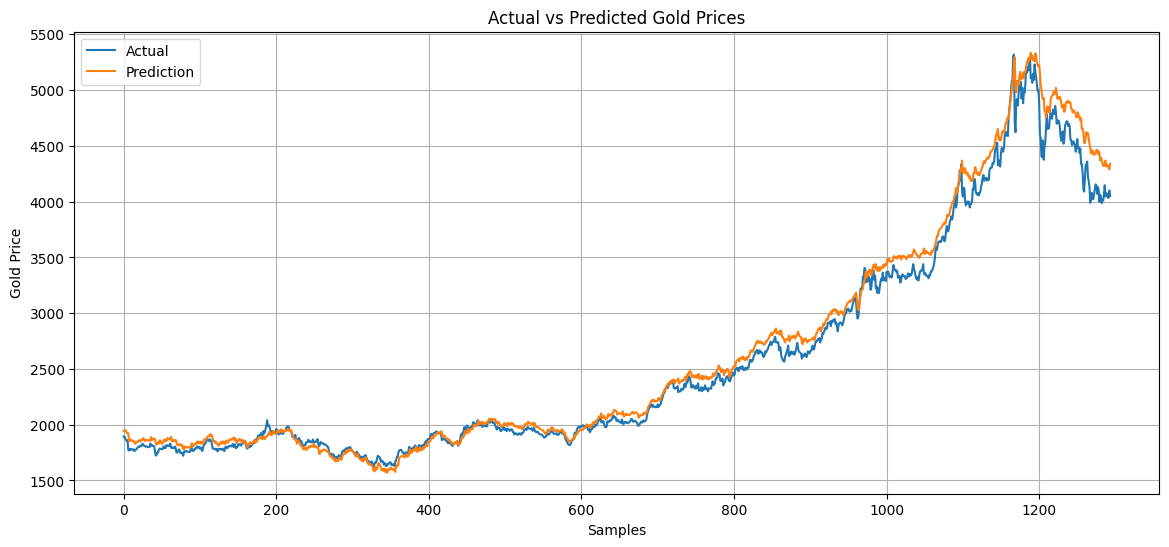

In [26]:
model.evaluate(X_test, y_test)

In [27]:
model.save("gold_model.keras")